### Se pide, usando regresión lineal:

Dibujar con una línea la relación que hay entre la altura y la edad de los alumnos de esta clase: 

In [19]:
lista_alumnos = [("Leonardo S", 24, 1.82), 
                 ("Piero T", 25, 1.71), 
                 ("Marta B", 35, 1.66), 
                 ("Silvia P", 37, 1.63), 
                 ("Faro Z", 29, 1.90), 
                 ("Miguel N", 27, 1.80), 
                 ("Alejandro M", 28, 1.70), 
                 ("Cristina M", 32, 1.60), 
                 ("Francisco P", 36, 1.74), 
                 ("Jorge D", 45, 1.72), 
                 ("Jesús L", 41, 1.65), 
                 ("Marta G", 30, 1.65), 
                 ("Jennifer S", 40, 1.60), 
                 ("Diego I", 39, 1.80), 
                 ("Antonio C", 23, 1.77), 
                 ("Juan M", 32, 1.75), 
                 ("David S", 27, 1.70), 
                 ("Antonio J", 34, 1.80), 
                 ("Carlos H", 27, 1.77), 
                 ("Erik U", 28, 1.70), 
                 ("Marcos L", 35, 1.80)] 

In [20]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df_alumnos = pd.DataFrame(lista_alumnos, columns=["Nombre", "Edad", "Altura (m)"])
df_alumnos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Nombre      21 non-null     object 
 1   Edad        21 non-null     int64  
 2   Altura (m)  21 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 636.0+ bytes


<Axes: xlabel='Edad', ylabel='Altura (m)'>

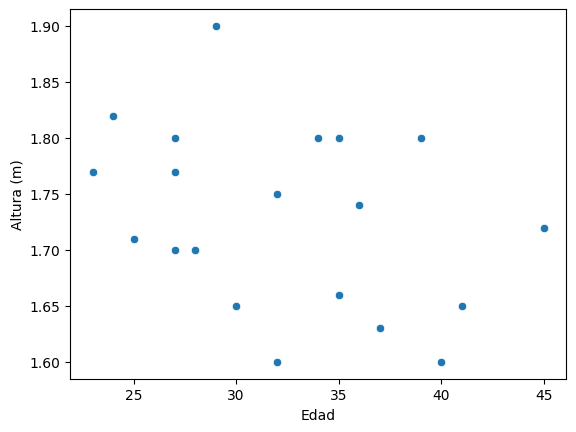

In [41]:
sns.scatterplot(df_alumnos, x="Edad", y="Altura (m)")

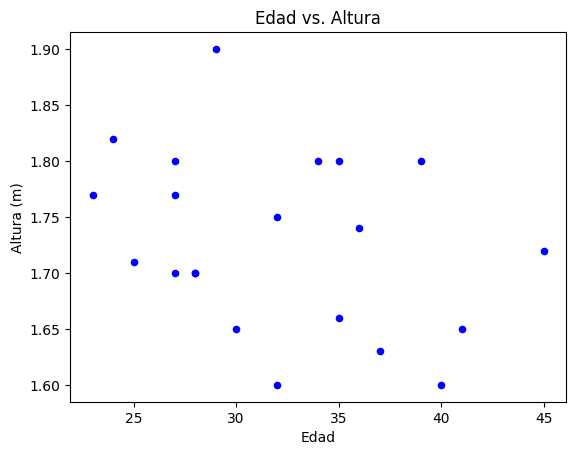

In [ ]:
df_alumnos.plot.scatter(x="Edad", y="Altura (m)", color="blue", title="Edad vs. Altura")

plt.show()

### ¿Es una buena técnica para este tipo de problemas? Demuéstralo antes de entrenar un modelo con un análisis descriptivo.

In [ ]:
# NO ES UNA BUENA TÉCNICA, NO PODEMOS HACER TEST SI SOLO TENEMOS 21 DATOS

### Entrena un modelo de regresión lineal

In [23]:
df_alumnos

,Nombre,Edad,Altura (m)
0,Leonardo S,24,1.82
1,Piero T,25,1.71
2,Marta B,35,1.66
3,Silvia P,37,1.63
4,Faro Z,29,1.90
5,Miguel N,27,1.80
6,Alejandro M,28,1.70
7,Cristina M,32,1.60
8,Francisco P,36,1.74
9,Jorge D,45,1.72


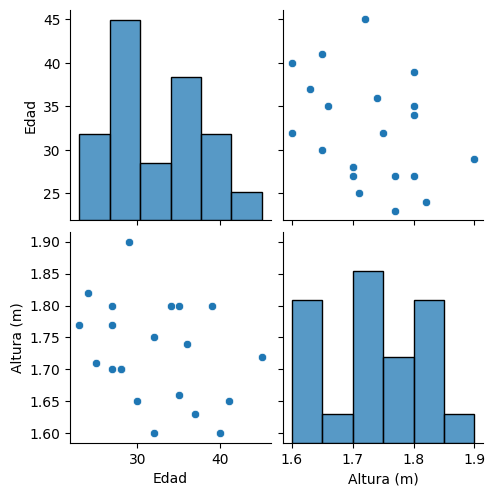

In [24]:
sns.pairplot(df_alumnos);

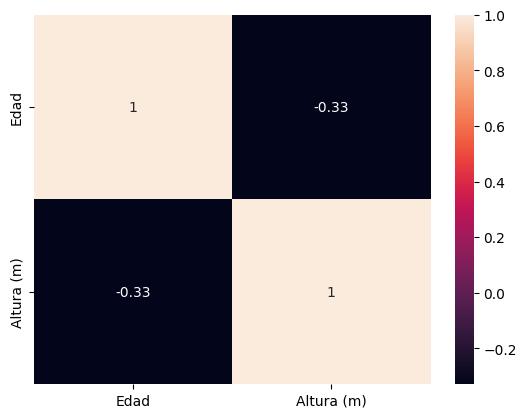

In [25]:
sns.heatmap(df_alumnos.corr(numeric_only=True), annot=True);

In [31]:
X = df_alumnos[['Edad']]
X

,Edad
0,24
1,25
2,35
3,37
4,29
5,27
6,28
7,32
8,36
9,45


In [32]:
y = df_alumnos['Altura (m)']
y


0     1.82
1     1.71
2     1.66
3     1.63
4     1.90
5     1.80
6     1.70
7     1.60
8     1.74
9     1.72
10    1.65
11    1.65
12    1.60
13    1.80
14    1.77
15    1.75
16    1.70
17    1.80
18    1.77
19    1.70
20    1.80
Name: Altura (m), dtype: float64

In [34]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()

In [35]:
lm.fit(X, y)

LinearRegression()

In [36]:
predictions = lm.predict (X)
predictions

array([1.76176751, 1.75749035, 1.71471872, 1.70616439, 1.74038169,
       1.74893602, 1.74465886, 1.72755021, 1.71044156, 1.67194709,
       1.68905574, 1.73610453, 1.6933329 , 1.69761007, 1.76604467,
       1.72755021, 1.74893602, 1.71899588, 1.74893602, 1.74465886,
       1.71471872])

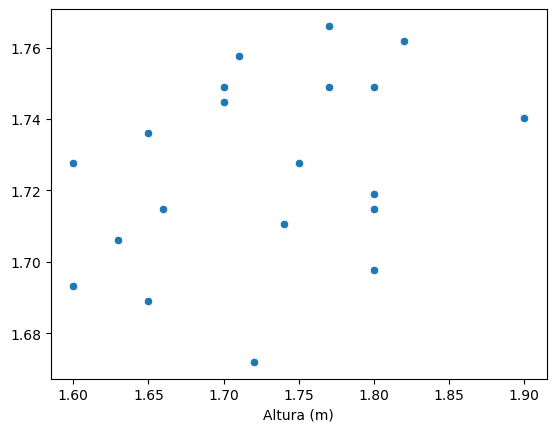

In [37]:
sns.scatterplot(x = y, y = predictions);

### ¿Qué error se comete? Calcula los errores que está cometiendo tu modelo de forma manual con python. Aparte, usa las métricas de sklearn MAE, MAPE, MSE y el RMSE.

In [38]:
from sklearn import metrics

In [39]:
lm.score(X, y)

0.10842201215661595

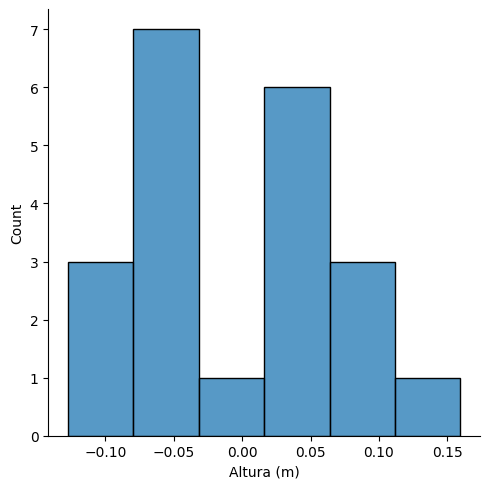

In [43]:
sns.displot((y - predictions));

In [44]:
print('MAE:', metrics.mean_absolute_error(y, predictions))
print('MAPE', metrics.mean_absolute_percentage_error(y, predictions))
print('MSE:', metrics.mean_squared_error(y, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y, predictions)))

MAE: 0.0631114830072091
MAPE 0.036581985019453755
MSE: 0.005299733644745233
RMSE: 0.07279926953442069
